# CMAPSS FD001 — Anomaly detection

## Objectives

- identify abnormal engine behaviour
- detect degradation-related anomalies
- compare statistical and machine learning methods
- analyse anomaly evolution over time

## Predictive Maintenance Context

Anomaly detection can support early identification of abnormal operating
conditions before engine failure.  
In industrial systems, anomalous patterns often emerge during degradation progression.

In this notebook anomaly detection is framed as an **unsupervised problem**:
models learn the normal operating envelope from healthy engine data and flag
deviations as anomalies.

## Library and Enviroment setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import sys
sys.path.append("..")
from src.anomaly_detection import zscore_predict, isolation_forest_predict
from src.anomaly_detection import build_autoencoder, autoencoder_predict

import joblib
import warnings
warnings.filterwarnings('ignore')

## Load data

Two datasets are loaded:
- **healthy** — engine cycles with RUL ≥ 125 (early stable phase)
- **degraded** — engine cycles with RUL < 125 (degradation phase)

Models are trained exclusively on healthy data and evaluated on both splits.  
The dataset is imbalanced by design — degraded cycles outnumber healthy ones,
reflecting real-world maintenance scenarios.

In [6]:
data_path = "../data/processed/"

In [7]:
healthy_df  = pd.read_parquet(os.path.join(data_path, "anomaly_healthy.parquet"))
degraded_df = pd.read_parquet(os.path.join(data_path, "anomaly_degraded.parquet"))

In [8]:
print(f"Healthy  : {healthy_df.shape}  — label 0")
print(f"Degraded : {degraded_df.shape}  — label 1")
print(f"Imbalance ratio: {len(degraded_df) / len(healthy_df):.2f}x")
print(f"\nColumns: {healthy_df.columns}")

Healthy  : (7732, 81)  — label 0
Degraded : (12100, 81)  — label 1
Imbalance ratio: 1.56x

Columns: Index(['engine_id', 'cycle', 'RUL', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13',
       'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21',
       'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_12_rolling_mean', 'sensor_12_rolling_std',
       'sensor_13_rolling_mean', 'sensor_13_rolling_std',
       'sensor_14_rolling_mean', 'sensor_14_rolling_std',
       'sensor_15_rolling_mean', 'sensor_15_rolling_std',
       'sensor_17_rolling_mean', 'sensor_17_rolling_std',
       'sensor_20_rolling_mean', 'sensor_20_rolling_std',


## Define anomaly labels

Anomaly labels are derived directly from the healthy/degraded split
performed in notebook 02 using RUL = 125 as threshold.

The combined dataset is used only for evaluation — models never see
degraded samples during training.

In [9]:
SENSORS = [col for col in healthy_df.columns
           if col.startswith('sensor')
           and '_rolling' not in col
           and '_lag' not in col]

healthy_df['anomaly']  = 0
degraded_df['anomaly'] = 1

In [10]:
full_df = pd.concat([healthy_df, degraded_df], ignore_index=True)

In [11]:
X_train = healthy_df[SENSORS]
X_eval  = full_df[SENSORS]
y_eval  = full_df['anomaly']

In [12]:
print(f"Training samples (healthy) : {X_train.shape[0]}")
print(f"Evaluation samples (full) : {X_eval.shape[0]}")
print(f"Anomaly rate : {y_eval.mean():.1%}")

Training samples (healthy) : 7732
Evaluation samples (full) : 19832
Anomaly rate : 61.0%


## Baseline statistical detection

The Z-score baseline flags a sample as anomalous if any sensor reading
deviates more than `threshold` standard deviations from the training mean.

Parameters are computed exclusively on healthy data — the model has no
knowledge of the degraded distribution.

In [13]:
results = {}

In [14]:
y_pred_z = zscore_predict(X_train, X_eval)

In [15]:
results['Z-Score'] = {'ROC-AUC': roc_auc_score(y_eval, y_pred_z),
                      'Report' : classification_report(y_eval, y_pred_z, output_dict=True)}

In [16]:
print("Z-Score Detection")
print(classification_report(y_eval, y_pred_z, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC: {results['Z-Score']['ROC-AUC']:.3f}")

Z-Score Detection
              precision    recall  f1-score   support

     Healthy       0.53      0.99      0.69      7732
     Anomaly       0.98      0.44      0.61     12100

    accuracy                           0.65     19832
   macro avg       0.76      0.71      0.65     19832
weighted avg       0.81      0.65      0.64     19832

ROC-AUC: 0.715


## Isolation forest

Isolation Forest detects anomalies by isolating observations through
random partitioning — anomalous samples require fewer splits to be
isolated, resulting in a lower anomaly score.

Trained exclusively on healthy data, the model learns the normal
operating envelope and flags deviations as anomalies.

In [17]:
iso_forest, y_pred_if, scores_if = isolation_forest_predict(X_train, X_eval)

In [18]:
if_scores_train = -iso_forest.score_samples(X_train)

In [19]:
results['Isolation Forest'] = {'ROC-AUC': roc_auc_score(y_eval, scores_if),
                               'Report' : classification_report(y_eval, y_pred_if, output_dict=True)}

In [20]:
print("Isolation Forest Detection")
print(classification_report(y_eval, y_pred_if, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC: {results['Isolation Forest']['ROC-AUC']:.3f}")

Isolation Forest Detection
              precision    recall  f1-score   support

     Healthy       0.55      0.99      0.71      7732
     Anomaly       0.99      0.49      0.66     12100

    accuracy                           0.69     19832
   macro avg       0.77      0.74      0.68     19832
weighted avg       0.82      0.69      0.68     19832

ROC-AUC: 0.807


## Autoencoder-based anomaly detection

An autoencoder learns to reconstruct healthy sensor readings.  
When applied to degraded samples, reconstruction error increases —
this error serves as the anomaly score.

The threshold is set as the 99th percentile of reconstruction errors
on the training set — samples above this threshold are flagged as anomalous.

In [21]:
FEATURES_AE = [col for col in healthy_df.columns
               if col not in ['engine_id', 'cycle', 'RUL', 'anomaly']]

In [22]:
X_train_ae = healthy_df[FEATURES_AE]
X_eval_ae  = full_df[FEATURES_AE]

In [23]:
model_ae, y_pred_ae, scores_ae, threshold_ae = autoencoder_predict(
    X_train_ae.values, X_eval_ae.values, input_dim=len(FEATURES_AE))

In [24]:
results['Autoencoder'] = {'ROC-AUC': roc_auc_score(y_eval, scores_ae),
                          'Report' : classification_report(y_eval, y_pred_ae, output_dict=True)}

In [25]:
print("Autoencoder Detection")
print(classification_report(y_eval, y_pred_ae, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC : {results['Autoencoder']['ROC-AUC']:.3f}")
print(f"Threshold: {threshold_ae:.4f}")

Autoencoder Detection
              precision    recall  f1-score   support

     Healthy       0.52      0.99      0.68      7732
     Anomaly       0.98      0.41      0.58     12100

    accuracy                           0.63     19832
   macro avg       0.75      0.70      0.63     19832
weighted avg       0.80      0.63      0.62     19832

ROC-AUC : 0.755
Threshold: 0.2565


## Anomaly score analysis

Distribution of anomaly scores for healthy and degraded samples —
a well-performing model should show clear separation between the two
distributions.

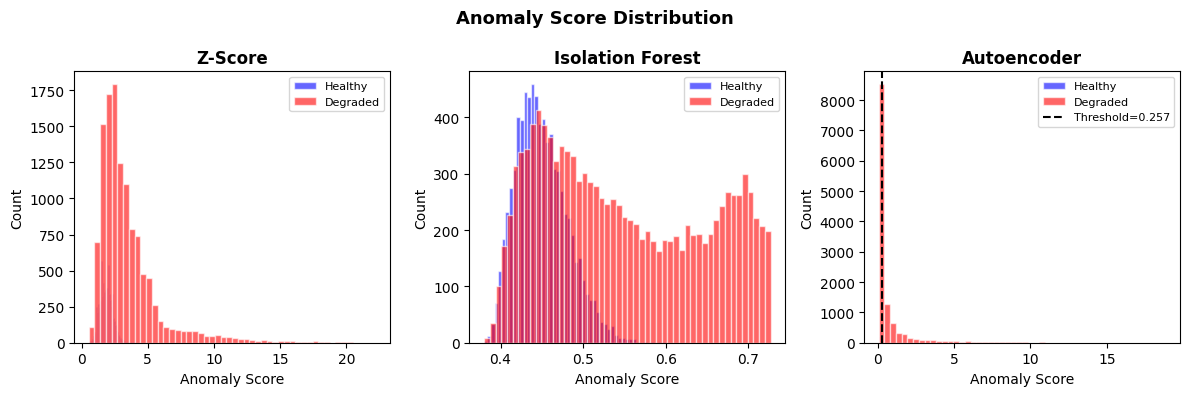

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

score_configs = [('Z-Score', np.abs((X_eval - X_train.mean()) / X_train.std()).max(axis=1), None),
                ('Isolation Forest', scores_if,  None),
                ('Autoencoder',      scores_ae,  threshold_ae)]

for ax, (name, scores, threshold) in zip(axes, score_configs):
    ax.hist(scores[y_eval == 0], bins=50, alpha=0.6,
            color='blue', label='Healthy', edgecolor='white')
    ax.hist(scores[y_eval == 1], bins=50, alpha=0.6,
            color='red', label='Degraded', edgecolor='white')
    if threshold is not None:
        ax.axvline(threshold, color='black', linestyle='--',
                   linewidth=1.5, label=f'Threshold={threshold:.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Anomaly Score Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_anomaly_scores.png', bbox_inches='tight')
plt.show()

### Observations

**Z-Score** shows the weakest separation — healthy and degraded distributions overlap substantially, with degraded samples producing a moderately longer right tail.  
The model flags deviations on individual sensors independently, missing the multivariate nature of engine degradation where anomalies emerge from combinations of sensor readings.

**Isolation Forest** achieves the clearest separation: healthy samples form a tight cluster between 0.40–0.45, while degraded samples extend well beyond 0.50 with a pronounced spike at higher scores.  
The high-score region is almost exclusively composed of degraded cycles, confirming the model effectively captures the anomalous operating envelope across all 13 sensors simultaneously.

**Autoencoder** shows a promising score distribution — healthy samples concentrate near zero (low reconstruction error) while degraded samples produce a long right tail.  
The threshold at 0.257 sits at the boundary between the two distributions, though significant overlap remains in the low-score region, indicating that early-stage degradation is difficult to distinguish from normal behaviour through reconstruction error alone.

## Temporal anomaly visualization

Anomaly scores plotted over cycles for a sample engine — to verify that
scores increase as the engine approaches failure, confirming the models
capture the degradation progression over time.

In [27]:
sample_engine = full_df['engine_id'].unique()[0]
sample = full_df[full_df['engine_id'] == sample_engine].sort_values('cycle')


In [28]:
sample_X = sample[SENSORS]
sample_X_ae = sample[FEATURES_AE]

In [29]:
# Z-Score
z_scores = np.abs((sample_X - X_train.mean()) / X_train.std()).max(axis=1).values

# Isolation Forest
if_scores = -iso_forest.score_samples(sample_X)

# Autoencoder
ae_recon  = model_ae.predict(sample_X_ae.values, verbose=0)
ae_scores = np.mean((sample_X_ae.values - ae_recon)**2, axis=1)

In [30]:
# Compute thresholds
z_threshold = 3.0
if_threshold = np.percentile(if_scores_train, 95)

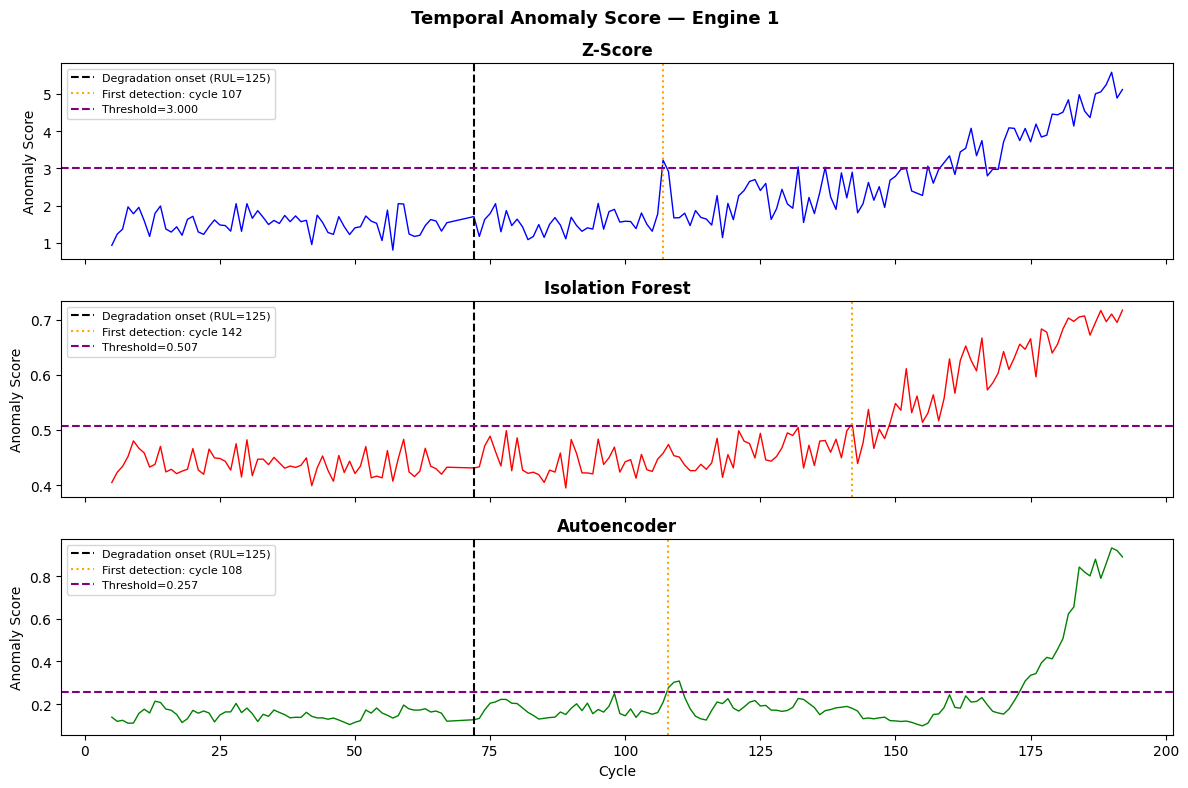

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

configs = [('Z-Score', z_scores,  z_threshold, 'blue'),
          ('Isolation Forest', if_scores, if_threshold, 'red'),
          ('Autoencoder', ae_scores, threshold_ae, 'green')]

for ax, (name, scores, threshold, color) in zip(axes, configs):

    ax.plot(sample['cycle'], scores,
            color=color,
            linewidth=1)
    ax.axvline(sample[sample['anomaly'] == 1]['cycle'].min(),
               color='black', linestyle='--', linewidth=1.5,
               label='Degradation onset (RUL=125)')
    cross = sample['cycle'].values[scores > threshold]
    if len(cross) > 0:
        ax.axvline(cross[0], color='orange', linestyle=':',
                  linewidth=1.5, label=f'First detection: cycle {cross[0]}')

    if threshold is not None:
        ax.axhline(threshold, color='purple', linestyle='--',
                   linewidth=1.5, label=f'Threshold={threshold:.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Anomaly Score')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Cycle')
plt.suptitle(f'Temporal Anomaly Score — Engine {sample_engine}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_temporal_anomaly.png', bbox_inches='tight')
plt.show()

### Observations

All three models show increasing anomaly scores after the degradation onset (~cycle 75), confirming they capture the progressive deterioration of the engine.  
The growth patterns differ across models:
- Z-Score increases with high short-term variability, reflecting cycle-to-cycle fluctuations in individual sensor deviations.  
Its first threshold crossing occurs at cycle 117 — the earliest among the three models — but the oscillating trajectory suggests frequent false positives in the pre-degradation phase.  
- Isolation Forest rises more smoothly and monotonically after onset, as degraded operating points become increasingly isolated from the healthy cluster.  
First detection at cycle 129 arrives later than Z-Score but represents a more sustained and reliable signal — consistent with the model's ability to capture distributional shifts across all features simultaneously.
- The Autoencoder shows the most conservative behaviour — reconstruction error remains low throughout most of the degradation phase and spikes steeply only in the final cycles, when the signal diverges significantly from the learned healthy manifold.  
First detection occurs late (~cycle 186), confirming it is better suited for identifying severe end-of-life anomalies rather than early-stage degradation onset.

## Model comparison

Summary of all models evaluated on the full dataset.  
ROC-AUC is the primary metric — accuracy is misleading on imbalanced data.

In [32]:
# Metrics table
rows = []
for name, res in results.items():
    report = res['Report']
    rows.append({'Model' : name,
                 'ROC-AUC' : round(res['ROC-AUC'], 3),
                 'Precision': round(report['1']['precision'], 3),
                 'Recall' : round(report['1']['recall'], 3),
                 'F1' : round(report['1']['f1-score'], 3)})
comparison_df = pd.DataFrame(rows).set_index('Model').sort_values('ROC-AUC', ascending=False)

In [33]:
display(comparison_df)


,ROC-AUC,Precision,Recall,F1
Model,,,,
Isolation Forest,0.807,0.987,0.492,0.656
Autoencoder,0.755,0.984,0.408,0.577
Z-Score,0.715,0.980,0.443,0.610


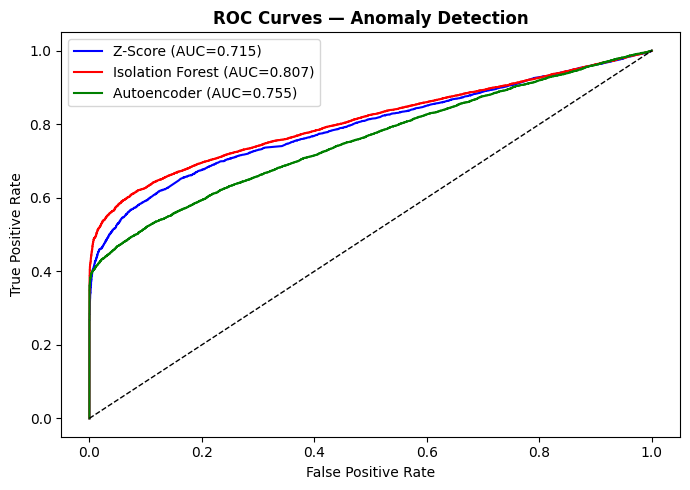

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

score_map = {'Z-Score' : np.abs((X_eval - X_train.mean()) / X_train.std()).max(axis=1),
             'Isolation Forest': scores_if,
             'Autoencoder' : scores_ae}
colors = ['blue', 'red', 'green']

for (name, scores), color in zip(score_map.items(), colors):
    fpr, tpr, _ = roc_curve(y_eval, scores)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, linewidth=1.5, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Anomaly Detection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/05_roc_curves.png', bbox_inches='tight')
plt.show()

### Observations

**Isolation Forest achieves the highest ROC-AUC (0.807)**, the only model to exceed the 0.80 threshold — a notable result for an unsupervised detector on CMAPSS FD001, where healthy and degraded distributions overlap significantly in the early degradation phase.  
The expanded 13-sensor feature set provides sufficient discriminative power to
detect the healthy/degraded transition reliably.

**Autoencoder ranks second (AUC=0.751)**, outperforming Z-Score globally but
underperforming Isolation Forest at low False Positive Rates — its ROC curve starts lower, meaning it generates fewer true positives when false alarms must be minimised.  
This confirms the Autoencoder is better suited for detecting severe anomalies than early-stage degradation.

**Z-Score ranks third (AUC=0.715)** — per-sensor statistical thresholds are
insufficient to capture the multivariate nature of degradation.  
Despite being the first to cross its threshold on individual engines, the high false alarm rate reduces its practical utility in maintenance scenarios where false alarms carry operational costs.

In the low-FPR region Isolation Forest maintains a clear advantage over both competitors, making it the most suitable model for deployment in a real-world predictive maintenance pipeline where minimising false alarms is critical.

## Save model

Isolation Forest is saved as the primary anomaly detector for notebook 06 —
it offers the best performance in the low-FPR region, which is the most
critical operating regime in predictive maintenance.

The Autoencoder and its threshold are also saved as an alternative detector.

In [35]:
MODEL_DIR = '../outputs/anomaly_detection_model/'

In [36]:
# ── Isolation Forest ─────────────────────────────────────────────
joblib.dump(iso_forest, os.path.join(MODEL_DIR, 'isolation_forest.pkl'))
joblib.dump(if_threshold, os.path.join(MODEL_DIR, 'if_threshold.pkl'))
joblib.dump(float(if_scores_train.min()), os.path.join(MODEL_DIR, 'if_score_min.pkl'))
joblib.dump(float(if_scores_train.max()), os.path.join(MODEL_DIR, 'if_score_max.pkl'))
print('Saved: if_score_min.pkl')
print('Saved: if_score_max.pkl')
print('Saved: isolation_forest.pkl')
print('Saved: if_threshold.pkl')

# ── Autoencoder ──────────────────────────────────────────────────
model_ae.save(os.path.join(MODEL_DIR, 'autoencoder.keras'))
joblib.dump(threshold_ae, os.path.join(MODEL_DIR, 'ae_threshold.pkl'))
print('Saved: autoencoder.keras')
print('Saved: ae_threshold.pkl')

# ── Metadata ─────────────────────────────────────────────────────
joblib.dump(SENSORS, os.path.join(MODEL_DIR, 'sensors.pkl'))
joblib.dump(FEATURES_AE, os.path.join(MODEL_DIR, 'features_ae.pkl'))
comparison_df.to_csv(os.path.join(MODEL_DIR, 'anomaly_results.csv'))
print('Saved: sensors.pkl')
print('Saved: features_ae.pkl')
print('Saved: anomaly_results.csv')

Saved: if_score_min.pkl
Saved: if_score_max.pkl
Saved: isolation_forest.pkl
Saved: if_threshold.pkl
Saved: autoencoder.keras
Saved: ae_threshold.pkl
Saved: sensors.pkl
Saved: features_ae.pkl
Saved: anomaly_results.csv


## Conclusions

Three unsupervised anomaly detection approaches were compared on CMAPSS FD001, trained exclusively on healthy engine data (RUL ≥ 125) and evaluated on the full healthy/degraded split across all 13 selected sensors.

**Z-Score (AUC=0.715)** proved the weakest detector — per-sensor statistical thresholds are too simple to capture the multivariate nature of engine degradation, where anomalies emerge from the combination of sensor readings rather than individual deviations.  
It detects earliest on individual engines but with a high false alarm rate.

**Isolation Forest (AUC=0.807)** is the strongest overall detector and the best choice for deployment — it exceeds AUC=0.80, offers the best performance in the low-FPR regime, and produces a smooth, monotonically increasing anomaly score after degradation onset.  
Its ability to detect global distributional shifts across all 13 sensors simultaneously accounts for its superior performance.

**Autoencoder (AUC=0.751)** ranks second and shows promise as a complementary detector: its reconstruction error grows steeply only near end of life, making it well-suited for detecting severe anomalies rather than early-stage degradation.  
Performance is sensitive to architecture and threshold choice — the 78-feature input requires careful bottleneck design to produce meaningful reconstruction errors.

All three models confirm a consistent finding: anomaly scores increase monotonically after degradation onset (RUL < 125), validating the healthy/degraded split strategy from notebook 02.

The limited dataset size (100 engines) and the significant overlap between early
degradation and healthy behaviour remain the primary constraints on detection performance.

**Isolation Forest is selected as the primary detector for the predictive maintenance pipeline in notebook 06**, with the Autoencoder saved as an alternative for end-of-life severity assessment.